# 구조체란?
* 하나 이상의 타입의 객체를 일렬로 모은 집합 Type

## 데이터 타입(stdio.h)
* 단일 데이터타입
  > 문자형: char    
  > 정수형: int, short, long, long long  
  > 실수형: float, double
* 집합 데이터타입
  > 구조체: struct  
  > 공용체: union  
  > 열거체: enum
  
* `stdbool.h` by C99표준
  >  bool형( true, false )  
  
```c
#include <stdio.h>
#include <stdbool.h>
 int main(){
    bool isTrue = true;
    bool isFalse = false;
    if(isTrue) printf(“이것은 true\n”);
    if(isFalse==0) printf(“이것은 false\n”);
}
```

## 구조체 정의
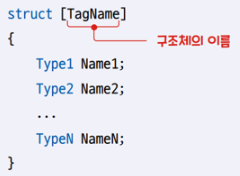  

## 구조체 정의 방법들

In [ ]:
#include <stdio.h>
int main(){
    // 구조체 정의 1 - 인스턴스(객체) 생성
    struct { 
        int m;
    } s;
    s.m = 3;
    printf("s.m: %d", s.m);
}

In [ ]:
#include <stdio.h>
// 구조체 정의 2 - 태그 사용
struct STag{
    int m;
};
int main(){
    struct STag s;
    s.m = 5;
    printf("s.m: %d",s.m);
}

In [ ]:
#include <stdio.h>
// 구조체 정의 3 - 사용자정의 데이터타입 생성, 여기서 STag는 옵션
typedef struct STag{
    int m;
} SType;
int main(){
    SType s2;
    s2.m = 5;
    SType* s3 = &s2; 
    printf("s2.m: %d, s3->m: %d",s2.m, s3->m);
}

In [ ]:
// 구조체 초기화
#include <stdio.h>
typedef struct {
    int m1;
    int m2;
    double m3;
} SType3;
int main(){
    SType3 s = { 3,5,7.7};
    printf("m1 = %d, m2 = %d, m3 = %.1lf\n", s.m1, s.m2, s.m3);
}

## 구조체 크기 측정
* 데이터타입의 크기: sizeof
* 구조체 멤버와 패딩의 개념:  메모리 영역을 해석할 때 읽거나 쓰지 않는 부분
* 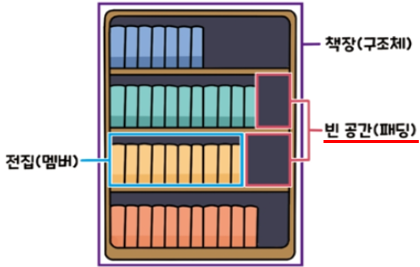
* 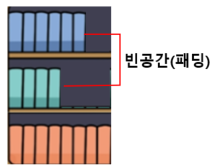

In [ ]:
//구조체 크기 측정
#include <stdio.h>
typedef struct {
    char c[6];
    int i;
    double d;
} SType;
int main(){
    SType s;
    printf("개별 데이터크기: %ld(char c[6]) + %ld(int) + %ld(double) = %ld\n", sizeof(s.c), sizeof(s.i), sizeof(s.d), sizeof(s.c)+sizeof(s.i)+sizeof(s.d));
    printf("SType 데이터크기: %ld\n", sizeof(s));
}        

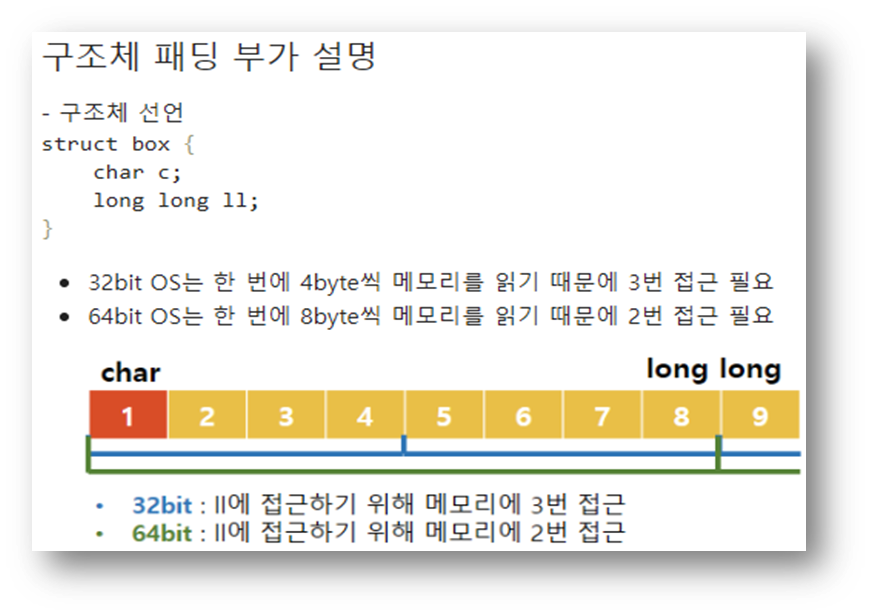  
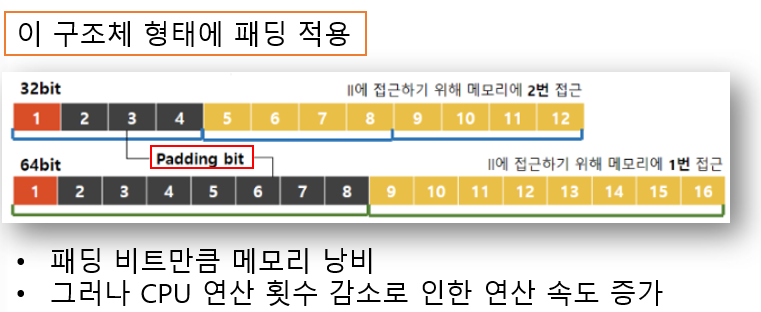

In [ ]:
//두번째 예시
#include <stdio.h>
int main(){
    struct box{
        char c[20];
        long long ll;
    } B;
    struct box B3[3];
    printf("개별 데이터크기: %ld(B.c) + %ld(B.ll) = %ld\n", sizeof(B.c), sizeof(B.ll), sizeof(B.c)+sizeof(B.ll));
    printf("구조체 데이터크기: %ld(B)\n", sizeof(B));
    printf("구조체 배열 데이터크기: %ld(B)\n", sizeof(B3));
}

# 포인터란?
* 메모리 주소를 저장하는 변수
* 데이터가 저장되어 있는 위치

```c
#include <stdio.h>
int main(){
    int a;
    int* p = &a;
    *p = 1;
    printf("a: %d(%p), *p: %d, p: %p, &p: %p",a,p,*p, p);
}

//결과
a: 1(0x7ffe8744817c), *p: 1, p: 0x7ffe8744817c, &p: 0x7ffe87448180
```

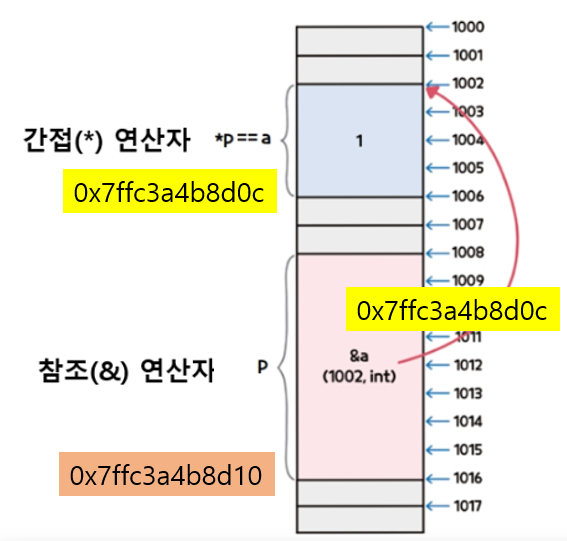<br>

In [ ]:
#include <stdio.h>
int main(){
    int a;
    int* p = &a;
    *p = 1;
    printf("a: %d(%p)\n*p: %d\np: %p\n&p: %p",a,p,*p, p,&p);
}

## 대상 타입과 객체 타입이 다른 포인터
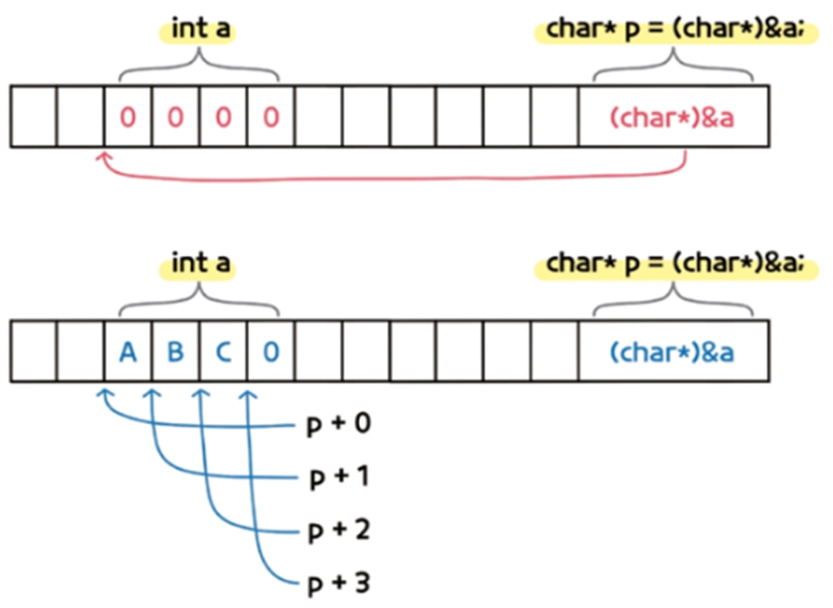

In [ ]:
//예시 : 정수형 <--> 문자형
#include <stdio.h>
int main(){
    int a = 0;
    char* p = (char *)&a;
    printf("a == *p == %d\n",a);
    *(p+0) = 'A';
    *(p+1) = 'B';
    *(p+2) = 'C';
    *(p+3) = '\0';
    for(int i=0;i<4;i++) printf("*(p+%d) = %c(%p)\n",i,*(p+i),p);
    printf("\na = %d(%p==%p)\n 정수형a를 문자열로 => %s\n",a,&a,p,&a);    
}

## 구조체와 포인터

```c
#include <stdio.h>
typedef struct {
    int m;
    char* str1;
    char* str2;
} SType;
int main(){
    SType S;
    SType* pS = &S;
    pS->m = 2025;
    pS->str1 = "Happy ";  //간접멤버 연산자
    (*pS).str2 = "New Year !!!"; //직접멤버 연산자
    printf("S.m = %d\nS.str1 = %s\nS.str2 = %s",S.m, S.str1, S.str2);
}
```

## 구조체와 포인터 활용
1. 직접 멤버 연산자
   
```c
#include <stdio.h>
//직접 멤버 연산자
typedef struct Student{
    char name[20];
    int age;
    float grade;
} SS;
int main(){
    SS s1 = {"Hong", 25, 9.9};
    printf("Name: %s, Age: %d, Grade: %.1f", s1.name, s1.age, s1.grade);
}
```

---  
2. 간접 멤버 연산자  

```c
#include <stdio.h>
#include <malloc.h>
//간접 멤버 연산자
typedef struct Student{
    char name[20];
    int age;
    float grade;
} SS;
int main(){
    SS *sptr = (SS*)malloc(sizeof(SS));
    strcpy(sptr->name, "Kim");
    sptr->age = 22;
    sptr->grade = 7.7;    
    printf("Name: %s, Age: %d, Grade: %.1f", sptr->name, sptr->age, sptr->grade);
}
```

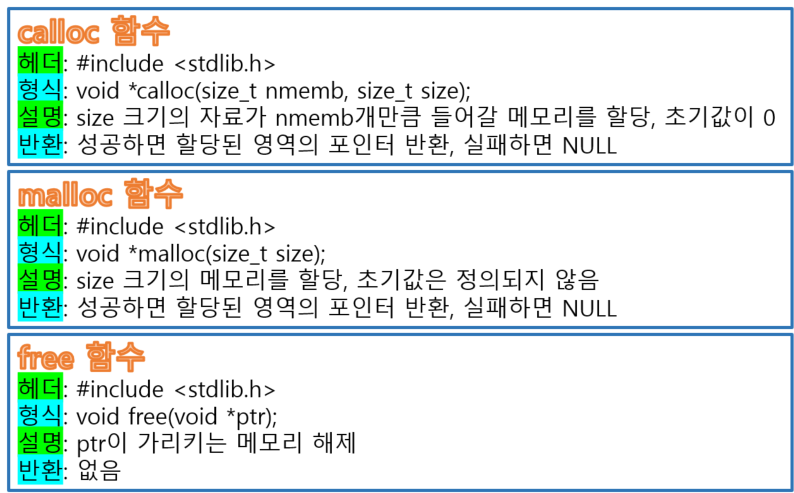

In [ ]:
//직접 멤버 연산자

In [ ]:
//간접 멤버 연산자

## 객체 가시 범위 및 생명 주기
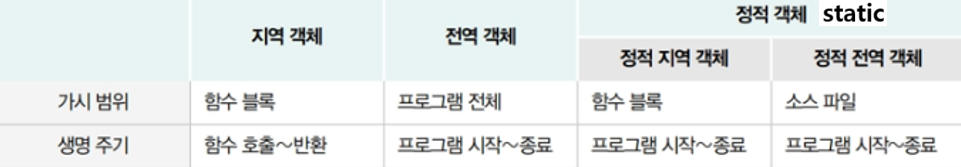

## 메모리 구조
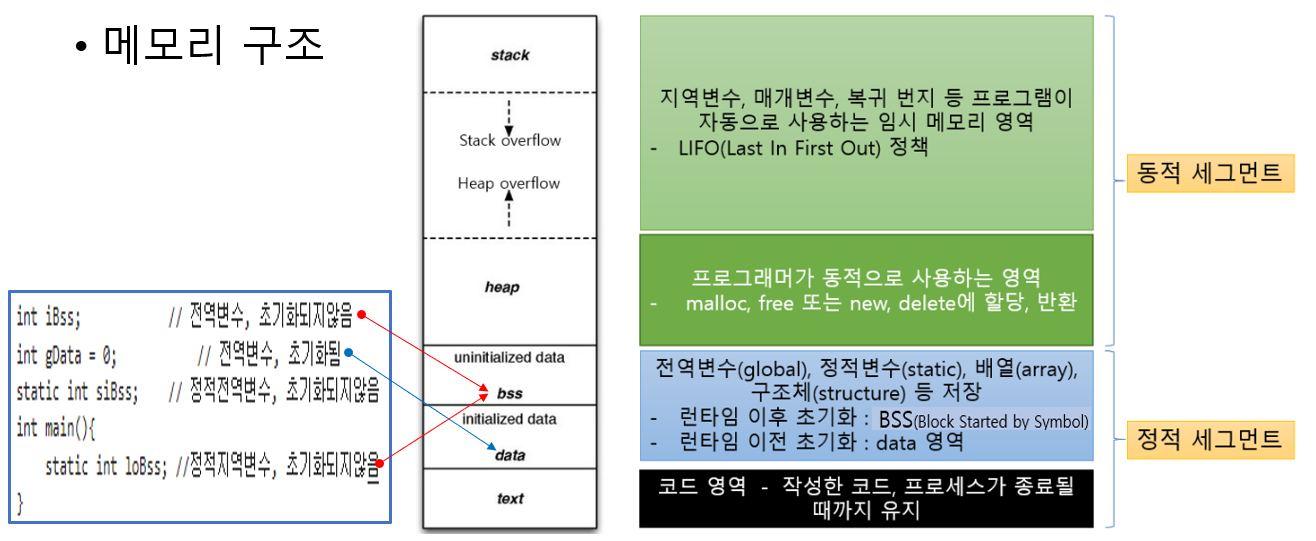